In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_selection import SelectFromModel
# !pip install imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# import warnings
# warnings.filterwarnings("ignore")

import sys
init_dir = os.getcwd()

In [2]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [3]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [4]:
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [5]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [7]:
# Cell 3: Train-validation split at consumer level
X_consumer = consumer_df.drop(columns='FPF_TARGET')
y_consumer = consumer_df['FPF_TARGET']

X_train_consumer, X_val_consumer, y_train, y_val = train_test_split(
    X_consumer, y_consumer,
    stratify=y_consumer,
    test_size=0.2,
    random_state=42
)

train_ids = X_train_consumer['masked_consumer_id']
val_ids = X_val_consumer['masked_consumer_id']
transaction_df_train = transactions_df[transactions_df['masked_consumer_id'].isin(train_ids)]

In [8]:
transaction_df_train

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date
0,C01103696,2022-05-02,400.00,1.0,C01T04156275,2022-09-15
1,C01103696,2022-06-09,38.00,1.0,C01T04156276,2022-09-15
2,C01103696,2022-08-13,4.00,6.0,C01T04156277,2022-09-15
3,C01103696,2022-09-13,0.17,7.0,C01T04156278,2022-09-15
4,C01103696,2022-02-24,2095.00,1.0,C01T04156279,2022-09-15
...,...,...,...,...,...,...
4477898,C01102466,2022-08-18,120.00,6.0,C01T02770845,2022-08-22
4477899,C01102466,2022-06-16,57.46,2.0,C01T02770846,2022-08-22
4477900,C01102466,2022-01-07,2273.99,5.0,C01T02770847,2022-08-22
4477901,C01102466,2022-08-08,35.14,2.0,C01T02770848,2022-08-22


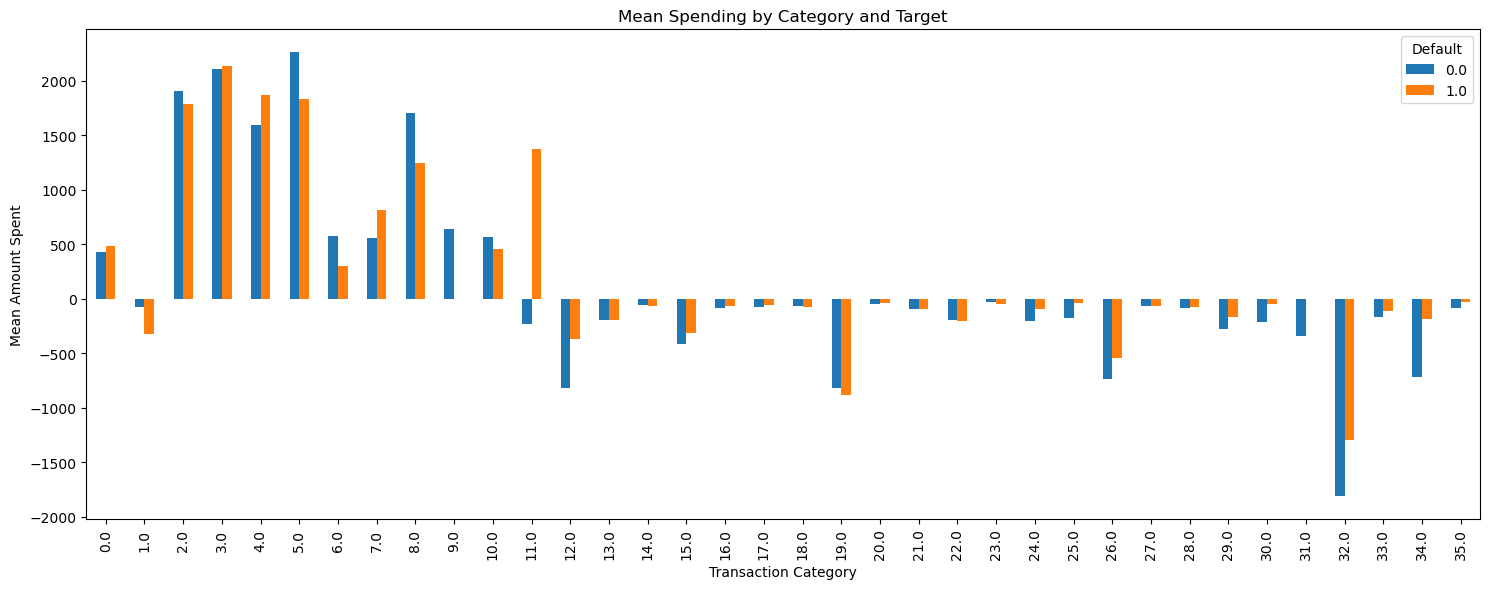

In [70]:

# Merge consumer_df with transaction_df
df = transaction_df_train.merge(consumer_df[['masked_consumer_id', 'FPF_TARGET']], on='masked_consumer_id', how='left')

# Total amount per category by target
category_mean = df.groupby(['category', 'FPF_TARGET'])['amount'].mean().unstack().fillna(0)
category_mean.plot(kind='bar', figsize=(15,6))
plt.title("Mean Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Mean Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()


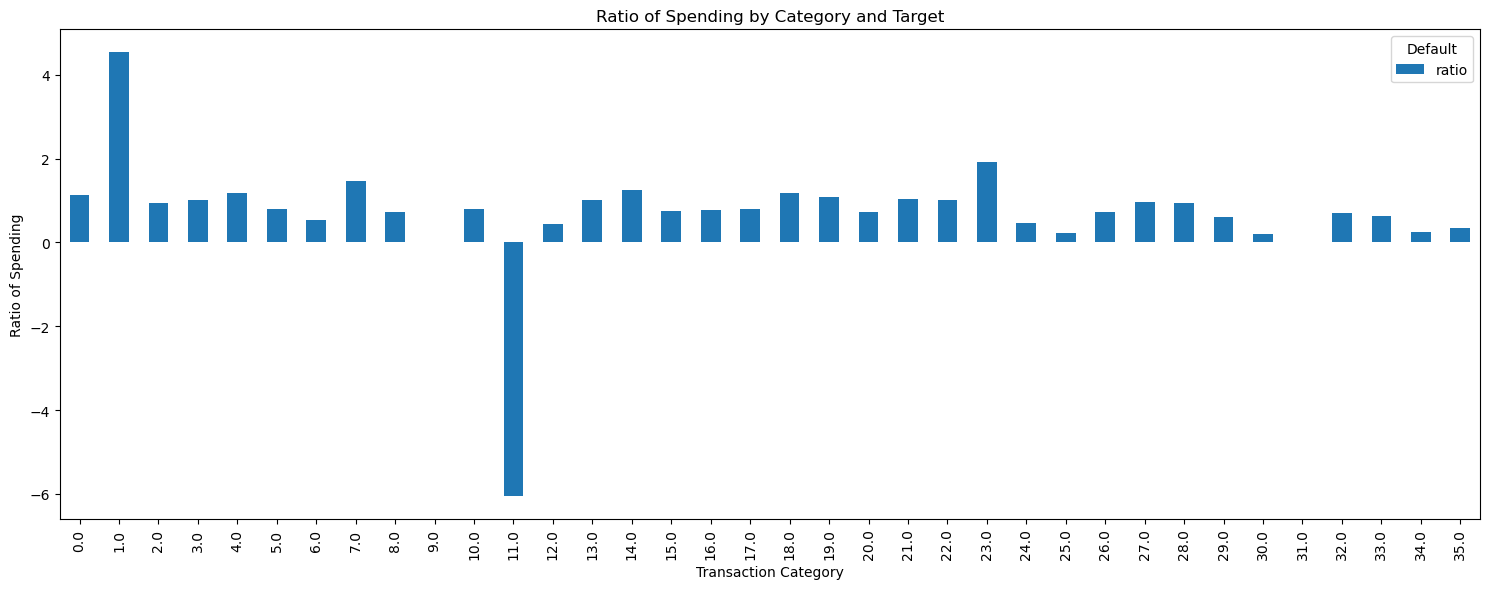

In [72]:
category_mean['ratio'] = category_mean[1] / category_mean[0]
category_mean['ratio'].plot(kind='bar', figsize=(15,6))
plt.title("Ratio of Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Ratio of Spending")
plt.legend(title="Default")
plt.tight_layout()
plt.show()

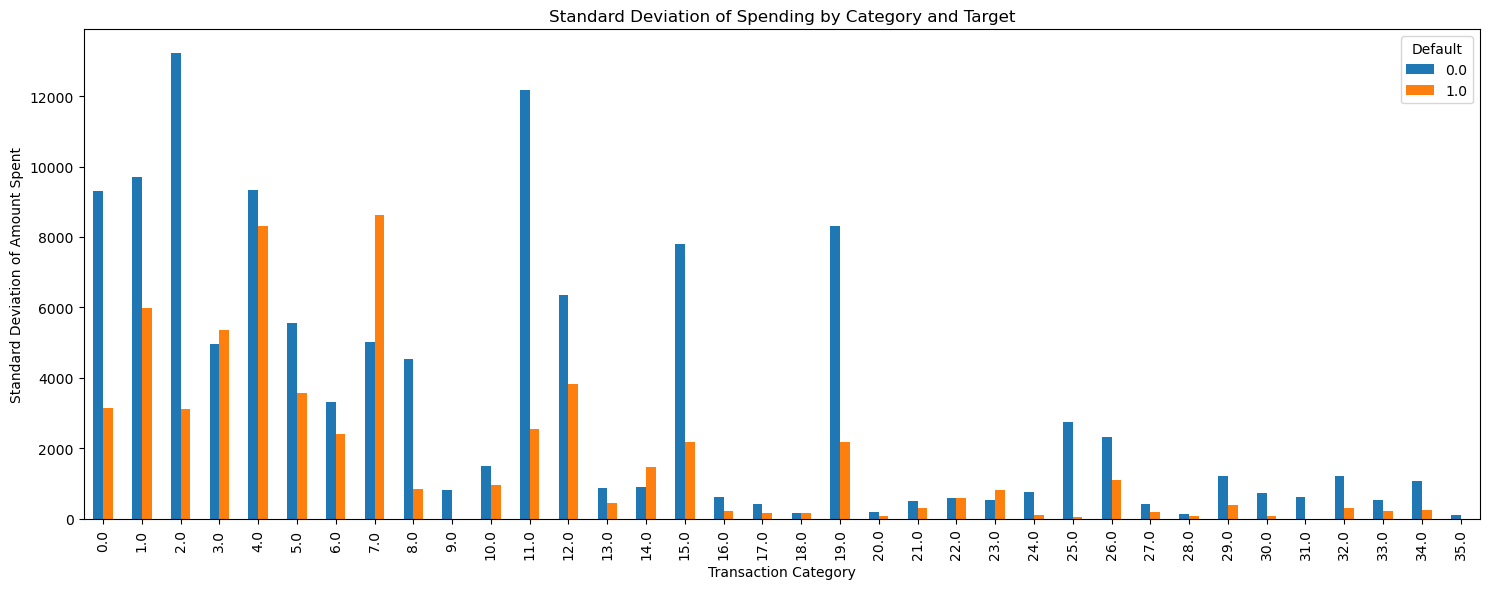

In [73]:
category_std = df.groupby(['category', 'FPF_TARGET'])['amount'].std().unstack().fillna(0)
category_std.plot(kind='bar', figsize=(15,6))
plt.title("Standard Deviation of Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Standard Deviation of Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()

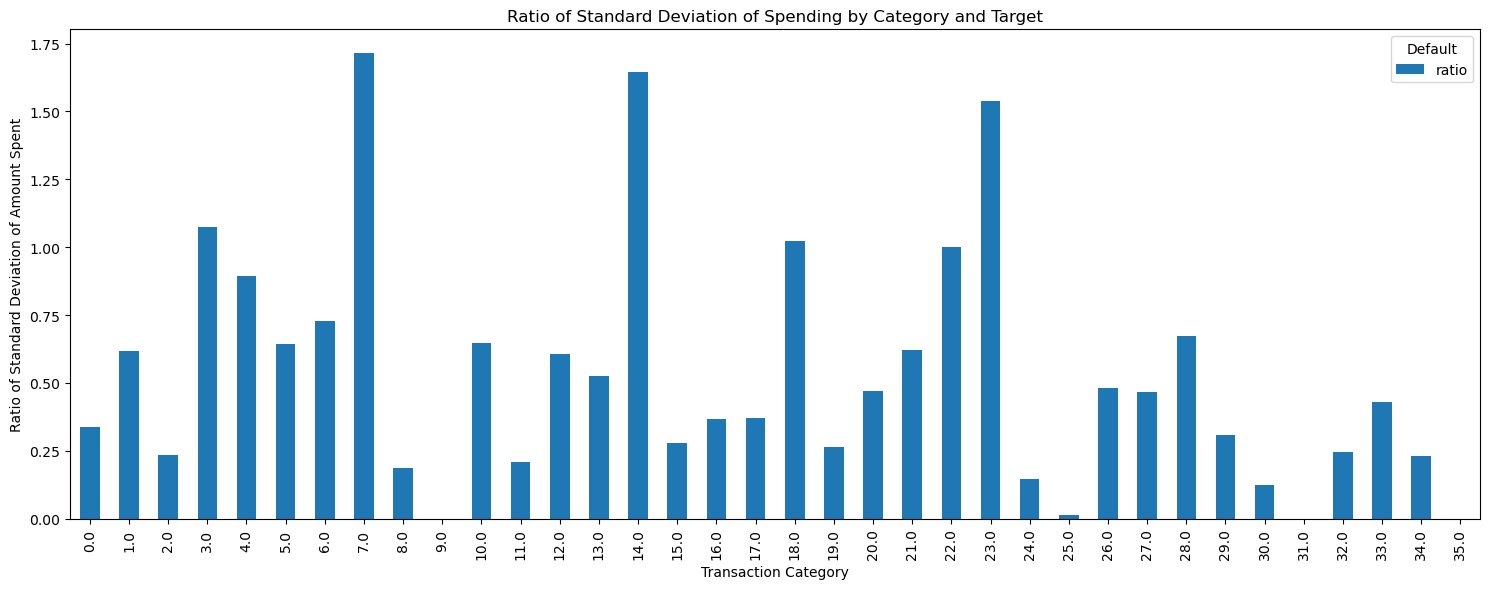

In [74]:
category_std['ratio'] = category_std[1] / category_std[0]
category_std['ratio'].plot(kind='bar', figsize=(15,6))
plt.title("Ratio of Standard Deviation of Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Ratio of Standard Deviation of Amount Spent")
plt.legend(title="Default")
plt.tight_layout()

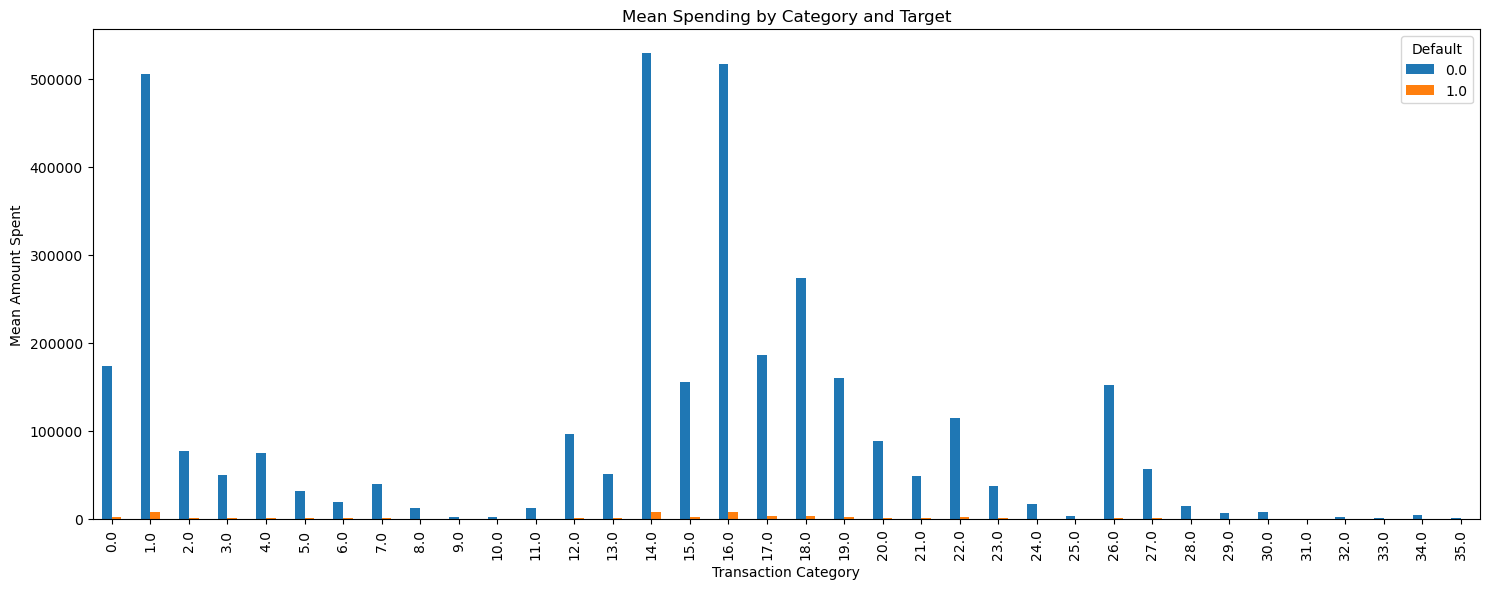

In [42]:
category_count = df.groupby(['category', 'FPF_TARGET'])['amount'].count().unstack().fillna(0)
category_count.plot(kind='bar', figsize=(15,6))
plt.title("Mean Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Mean Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()


In [29]:
def credit_debit_gap(df):
    pos = df[df['amount'] > 0].groupby('category')['amount'].sum()
    neg = df[df['amount'] < 0].groupby('category')['amount'].sum().abs()
    gap = (pos - neg).fillna(0)
    return gap

gap_df = df.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)
gap_df

/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_76810/2090609864.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_df = df.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)


category,gap_cat_0.0,gap_cat_1.0,gap_cat_2.0,gap_cat_3.0,gap_cat_4.0,gap_cat_5.0,gap_cat_6.0,gap_cat_7.0,gap_cat_8.0,gap_cat_9.0,...,gap_cat_26.0,gap_cat_27.0,gap_cat_28.0,gap_cat_29.0,gap_cat_30.0,gap_cat_31.0,gap_cat_32.0,gap_cat_33.0,gap_cat_34.0,gap_cat_35.0
masked_consumer_id,,,,,,,,,,,,,,,,,,,,,
C01100001,0.00,-149038.51,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01100003,0.00,-1313.65,0.0,57809.69,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01100004,0.00,-40341.34,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01100006,0.00,-152019.74,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01100007,0.00,-803.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C01104996,-7657.84,59744.66,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01104997,0.00,19240.30,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C01104998,0.00,-10966.42,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET
0,C01103696,2022-05-02,400.00,1.0,C01T04156275,2022-09-15,0.0
1,C01103696,2022-06-09,38.00,1.0,C01T04156276,2022-09-15,0.0
2,C01103696,2022-08-13,4.00,6.0,C01T04156277,2022-09-15,0.0
3,C01103696,2022-09-13,0.17,7.0,C01T04156278,2022-09-15,0.0
4,C01103696,2022-02-24,2095.00,1.0,C01T04156279,2022-09-15,0.0
...,...,...,...,...,...,...,...
3565639,C01102466,2022-08-18,120.00,6.0,C01T02770845,2022-08-22,0.0
3565640,C01102466,2022-06-16,57.46,2.0,C01T02770846,2022-08-22,0.0
3565641,C01102466,2022-01-07,2273.99,5.0,C01T02770847,2022-08-22,0.0
3565642,C01102466,2022-08-08,35.14,2.0,C01T02770848,2022-08-22,0.0


In [54]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif, f_classif, SelectKBest
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier

# Step 1: Feature Generation Pipeline
def generate_transaction_features(transactions, consumer_ids, target_df=None):
    subset = transactions[transactions['masked_consumer_id'].isin(consumer_ids)].copy()

    # Basic Aggregation
    base_features = subset.groupby('masked_consumer_id')['amount'].agg(['sum', 'mean', 'std', 'min', 'max', 'median', 'count'])
    base_features.columns = ['total_amount', 'mean_amount', 'std_amount', 'min_amount', 'max_amount', 'median_amount', 'transaction_count']

    # Category-Specific Spending
    cat_spending = subset.pivot_table(index='masked_consumer_id', columns='category', values='amount', aggfunc='sum', fill_value=0)
    cat_spending.columns = [f'spend_cat_{int(c)}' for c in cat_spending.columns]

    # Credit-Debit Gap per Category
    def credit_debit_gap(df):
        pos = df[df['amount'] > 0].groupby('category')['amount'].sum()
        neg = df[df['amount'] < 0].groupby('category')['amount'].sum().abs()
        return (pos - neg).fillna(0)

    gap_df = subset.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)

    # Binary Category Usage
    usage = pd.crosstab(subset['masked_consumer_id'], subset['category']).astype(bool).astype(int)
    usage.columns = [f'used_cat_{int(c)}' for c in usage.columns]

    # Timing Features per Category
    cat_days = subset.groupby(['masked_consumer_id', 'category'])['posted_date'].agg(['min', 'max', 'count'])
    cat_days['duration'] = (cat_days['max'] - cat_days['min']).dt.days
    cat_days['txn_gap'] = cat_days['duration'] / cat_days['count'].replace(0, 1)
    duration_feat = cat_days['txn_gap'].unstack().fillna(0).add_prefix('gap_days_cat_')

    # Monthly volatility
    subset['month'] = subset['posted_date'].dt.to_period('M')
    monthly_cashflow = subset.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
        columns={'mean': 'monthly_mean', 'std': 'monthly_std'}).fillna(0)

    # Combine All
    features_df = base_features.join(cat_spending, how='left') \
                               .join(gap_df, how='left') \
                               .join(usage, how='left') \
                               .join(duration_feat, how='left') \
                               .join(monthly_stats, how='left') \
                               .fillna(0).reset_index()

    if target_df is not None:
        features_df = features_df.merge(target_df, on='masked_consumer_id', how='left')

    return features_df


# Step 2: Feature Selection Pipeline
def select_features_pipeline(X, y, top_k=50):
    # Initial filtering with ANOVA and Mutual Information
    anova_selector = SelectKBest(f_classif, k=top_k).fit(X, y)
    mi_selector = SelectKBest(mutual_info_classif, k=top_k).fit(X, y)

    # Intersection of both methods
    selected_features = list(set(X.columns[anova_selector.get_support()]) | set(X.columns[mi_selector.get_support()]))

    X_filtered = X[selected_features]

    # XGBoost CV for stable importance
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    feature_importances = []

    for train_idx, val_idx in skf.split(X_filtered, y):
        model = XGBClassifier(
            n_estimators=200,
            max_depth=3,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.0,
            learning_rate=0.05,
            random_state=42
        )
        model.fit(X_filtered.iloc[train_idx], y.iloc[train_idx])
        feature_importances.append(model.feature_importances_)

    avg_importance = np.mean(feature_importances, axis=0)
    importance_df = pd.DataFrame({
        'feature': X_filtered.columns,
        'importance': avg_importance
    }).sort_values(by='importance', ascending=False)

    # Final Selection: keep features with importance above median
    median_importance = importance_df['importance'].median()
    final_features = importance_df[importance_df['importance'] > median_importance]['feature'].tolist()

    return final_features





In [59]:
# Example Usage
X_train_df = generate_transaction_features(transactions_df, train_ids)
X_val_df = generate_transaction_features(transactions_df, val_ids)

X_train = X_train_consumer.merge(X_train_df, on='masked_consumer_id', how='left')
X_val = X_val_consumer.merge(X_val_df, on='masked_consumer_id', how='left')

# # Drop identifier
X_train = X_train.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)
X_val = X_val.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)

/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_76810/1066978843.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_df = subset.groupby('masked_consumer_id').apply(credit_debit_gap).unstack().add_prefix('gap_cat_').fillna(0)
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_76810/1066978843.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_df = subset.groupby('masked_consume

In [60]:
pd.set_option('display.max_columns', None)
X_train

,total_balance,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,spend_cat_0,spend_cat_1,spend_cat_2,spend_cat_3,spend_cat_4,spend_cat_5,spend_cat_6,spend_cat_7,spend_cat_8,spend_cat_9,spend_cat_10,spend_cat_11,spend_cat_12,spend_cat_13,spend_cat_14,spend_cat_15,spend_cat_16,spend_cat_17,spend_cat_18,spend_cat_19,spend_cat_20,spend_cat_21,spend_cat_22,spend_cat_23,spend_cat_24,spend_cat_25,spend_cat_26,spend_cat_27,spend_cat_28,spend_cat_29,spend_cat_30,spend_cat_31,spend_cat_32,spend_cat_33,spend_cat_34,spend_cat_35,gap_cat_0.0,gap_cat_1.0,gap_cat_2.0,gap_cat_3.0,gap_cat_4.0,gap_cat_5.0,gap_cat_6.0,gap_cat_7.0,gap_cat_8.0,gap_cat_9.0,gap_cat_10.0,gap_cat_11.0,gap_cat_12.0,gap_cat_13.0,gap_cat_14.0,gap_cat_15.0,gap_cat_16.0,gap_cat_17.0,gap_cat_18.0,gap_cat_19.0,gap_cat_20.0,gap_cat_21.0,gap_cat_22.0,gap_cat_23.0,gap_cat_24.0,gap_cat_25.0,gap_cat_26.0,gap_cat_27.0,gap_cat_28.0,gap_cat_29.0,gap_cat_30.0,gap_cat_31.0,gap_cat_32.0,gap_cat_33.0,gap_cat_34.0,gap_cat_35.0,used_cat_0,used_cat_1,used_cat_2,used_cat_3,used_cat_4,used_cat_5,used_cat_6,used_cat_7,used_cat_8,used_cat_9,used_cat_10,used_cat_11,used_cat_12,used_cat_13,used_cat_14,used_cat_15,used_cat_16,used_cat_17,used_cat_18,used_cat_19,used_cat_20,used_cat_21,used_cat_22,used_cat_23,used_cat_24,used_cat_25,used_cat_26,used_cat_27,used_cat_28,used_cat_29,used_cat_30,used_cat_31,used_cat_32,used_cat_33,used_cat_34,used_cat_35,gap_days_cat_0.0,gap_days_cat_1.0,gap_days_cat_2.0,gap_days_cat_3.0,gap_days_cat_4.0,gap_days_cat_5.0,gap_days_cat_6.0,gap_days_cat_7.0,gap_days_cat_8.0,gap_days_cat_9.0,gap_days_cat_10.0,gap_days_cat_11.0,gap_days_cat_12.0,gap_days_cat_13.0,gap_days_cat_14.0,gap_days_cat_15.0,gap_days_cat_16.0,gap_days_cat_17.0,gap_days_cat_18.0,gap_days_cat_19.0,gap_days_cat_20.0,gap_days_cat_21.0,gap_days_cat_22.0,gap_days_cat_23.0,gap_days_cat_24.0,gap_days_cat_25.0,gap_days_cat_26.0,gap_days_cat_27.0,gap_days_cat_28.0,gap_days_cat_29.0,gap_days_cat_30.0,gap_days_cat_31.0,gap_days_cat_32.0,gap_days_cat_33.0,gap_days_cat_34.0,gap_days_cat_35.0,monthly_mean,monthly_std
0,20312.17,19363.50,81.359244,1321.435222,-1681.77,19000.0,-19.95,238.0,0.000000e+00,-651.08,0.00,0.00,2945.04,15324.55,0.00,0.02,0.00,0.0,0.0,429.00,13954.69,0.00,-1762.18,-925.11,-1602.30,-69.08,-260.39,-1001.19,-389.18,-92.36,-1622.90,0.00,0.00,0.0,-4800.00,-108.06,0.00,0.00,0.00,0.0,0.0,0.0,-5.97,0.00,0.00,-651.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,13954.69,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,1.950000,0.000000,0.000000,5.923077,12.166667,0.000000,16.000000,0.000000,0.0,0.0,0.000000,19.000000,0.000000,1.354839,5.153846,2.076923,7.000000,10.666667,19.666667,10.000000,16.500000,4.764706,0.000000,0.000000,0.0,9.750000,9.625000,0.000000,0.0,0.000000,0.0,0.0,0.0,20.000000,0.0,4840.875000,7870.041786
1,74091.88,29902.29,22.774021,881.770844,-5030.00,7804.0,-36.05,1313.0,2.506500e+04,-43102.70,27258.12,0.00,75411.70,9220.60,52939.22,14.16,0.00,0.0,0.0,-8024.00,-50.00,-3337.35,-3813.13,0.00,-9869.94,-2582.64,-8872.43,-20080.50,-1337.19,-3807.68,-4907.58,0.00,-9.98,0.0,-46631.69,-826.74,-213.96,0.00,-2539.00,0.0,0.0,0.0,0.00,0.00,0.00,-43102.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8024.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.555556,2.203704,9.310345,0.000000,22.133333,29.166667,14.291667,27.666667,0.000000,0.0,0.0,39.000000,0.000000,23.266667,2.372549,0.000000,1.375479,5.181818,2.259494,5.343284,7.680851,5.758065,8.357143,0.000000,0.000000,0.0,3.113043,16.066667,62.600000,0.0,17.631579,0.0,0.0,0.0,0.000000,0.0,2300.176154,3266.571439
2,1639.45,1109.73,

In [53]:
y_train

3579    0.0
235     0.0
1739    0.0
2739    0.0
4351    0.0
       ... 
4973    0.0
1994    0.0
2359    0.0
2787    0.0
1762    0.0
Name: FPF_TARGET, Length: 3200, dtype: float64

In [63]:
# Feature Selection
final_feature_names = select_features_pipeline(X_train, y_train)

# Apply final selection
X_train_selected = X_train[final_feature_names]
X_val_selected = X_val[final_feature_names]

X_train_selected.shape

/opt/miniconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [46 48 49 50 51 52 53 54 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(3200, 35)

In [75]:
final_feature_names

['spend_cat_12',
 'spend_cat_26',
 'gap_days_cat_20.0',
 'spend_cat_23',
 'gap_days_cat_19.0',
 'spend_cat_3',
 'total_balance',
 'gap_days_cat_3.0',
 'spend_cat_21',
 'gap_cat_1.0',
 'spend_cat_1',
 'spend_cat_7',
 'spend_cat_2',
 'gap_days_cat_11.0',
 'gap_days_cat_21.0',
 'spend_cat_4',
 'gap_days_cat_23.0',
 'median_amount',
 'gap_days_cat_13.0',
 'spend_cat_24',
 'gap_days_cat_16.0',
 'spend_cat_28',
 'gap_days_cat_22.0',
 'total_amount',
 'gap_days_cat_27.0',
 'spend_cat_13',
 'max_amount',
 'gap_days_cat_26.0',
 'gap_days_cat_0.0',
 'spend_cat_5',
 'monthly_std',
 'gap_days_cat_17.0',
 'spend_cat_11',
 'gap_days_cat_5.0',
 'used_cat_24']

In [78]:
xgb_slc = XGBClassifier()
xgb_slc.fit(X_train_selected, y_train)

y_val_proba = xgb_slc.predict_proba(X_val_selected)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba) 
print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.6707


Model Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

Top 10 Most Important Features:
              feature  i

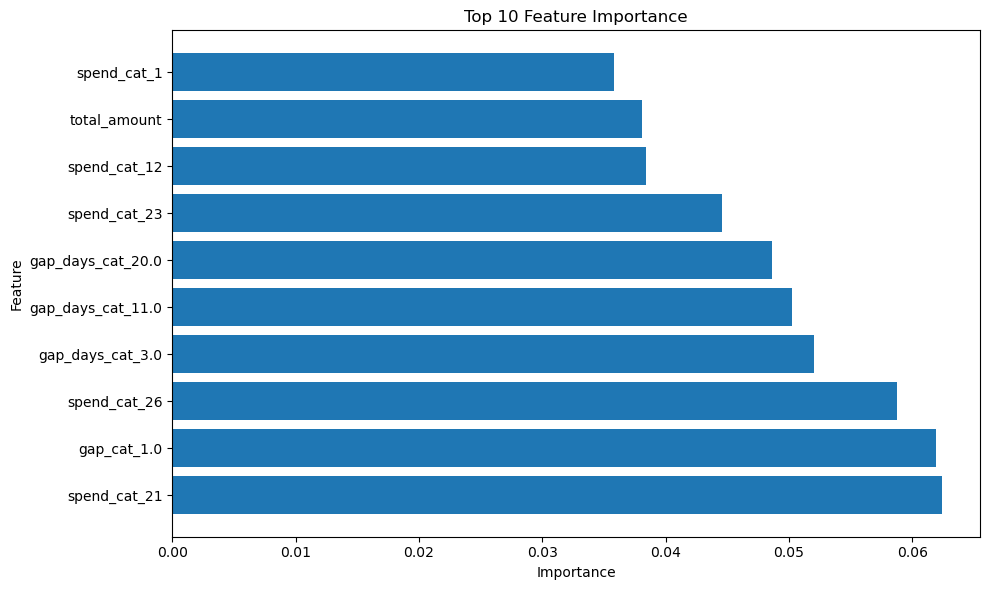

In [79]:
model = xgb_slc

# 2. Get model parameters
print("Model Parameters:")
print(model.get_params())

# 3. Get feature importance
# For XGBoost, you can get feature importance in different ways:
feature_importance = pd.DataFrame({
    'feature': X_train_selected.columns,  # Make sure X_train has the same columns as your training data
    'importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Display top features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Optional: Visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [77]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_val_proba = xgb.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba) 
print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.6563
